# 4. Metropolis–Hastings: `snia.bayes`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from snia.bayes.posterior import Posterior, UniformPrior
from snia.bayes.proposals import GaussianRandomWalk
from snia.bayes.samplers import MetropolisHastings, run_chains

plt.rcParams["figure.figsize"] = (7, 4)


def autocorrelation(chain, max_lag=60):
    # correlation of the chain with itself, lag by lag
    centred = chain - chain.mean()
    full = np.correlate(centred, centred, mode="full")
    from_zero_lag = full[len(centred) - 1:]
    return from_zero_lag[: max_lag + 1] / from_zero_lag[0]

## 1. The algorithm

Propose $\theta' \sim q(\cdot\mid\theta)$, then accept with

$$
\log u < \log\pi(\theta') - \log\pi(\theta)
+ \log q(\theta\mid\theta') - \log q(\theta'\mid\theta),
\qquad u \sim U(0,1).
$$

## 2. A one-dimensional target

Start with $\pi(x) = \mathcal{N}(0,1)$, where every answer is known.

In [2]:
log_normal = lambda theta: -0.5 * np.sum(np.asarray(theta) ** 2)

result = MetropolisHastings(
    log_target=log_normal,
    proposal=GaussianRandomWalk(cov=[[1.0]], scale=2.4),
).sample(initial_state=[3.0], n_steps=20000, rng=np.random.default_rng(0))

print(f"samples shape   {result.samples.shape}")
print(f"acceptance rate {result.acceptance_rate:.3f}")

samples shape   (20000, 1)
acceptance rate 0.440


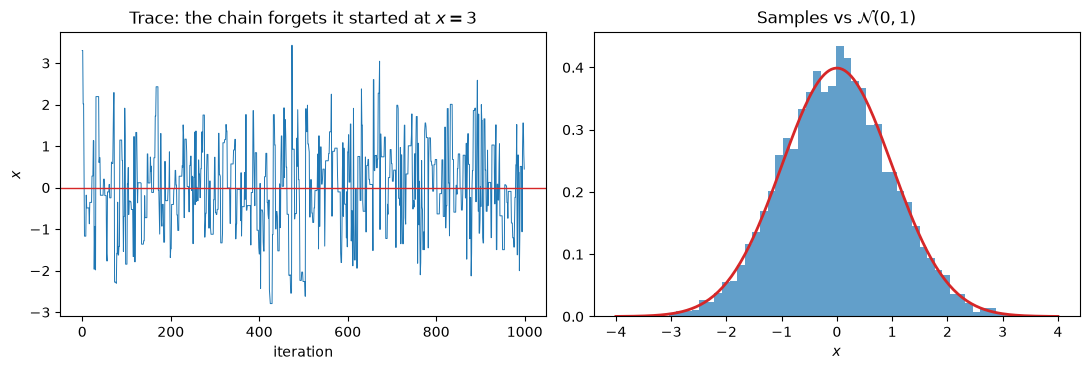

mean -0.0028  (truth 0)
std  0.9913  (truth 1)


In [3]:
figure, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))

left.plot(result.samples[:1000, 0], lw=0.7)
left.axhline(0, color="C3", lw=1)
left.set_xlabel("iteration")
left.set_ylabel("$x$")
left.set_title("Trace: the chain forgets it started at $x = 3$")

retained = result.samples[500:, 0]
right.hist(retained, bins=50, density=True, alpha=0.7)
grid = np.linspace(-4, 4, 200)
right.plot(grid, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi), "C3", lw=2)
right.set_xlabel("$x$")
right.set_title(r"Samples vs $\mathcal{N}(0,1)$")
plt.tight_layout()
plt.show()

print(f"mean {retained.mean():+.4f}  (truth 0)")
print(f"std  {retained.std():.4f}  (truth 1)")

## 3. The proposal scale

* **too small** — nearly everything is accepted, but the chain barely moves and
  successive samples are strongly correlated;
* **too large** — most proposals land where the density is negligible, so the
  chain sticks;
* **useful** — regular movement across the typical set.

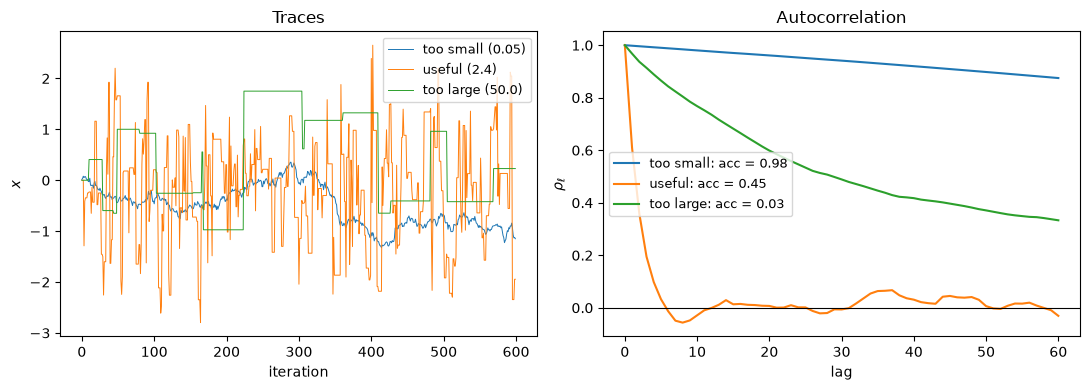

In [4]:
figure, (left, right) = plt.subplots(1, 2, figsize=(11, 4))

for scale, label in [(0.05, "too small"), (2.4, "useful"), (50.0, "too large")]:
    run = MetropolisHastings(log_normal, GaussianRandomWalk([[1.0]], scale)).sample(
        [0.0], 4000, np.random.default_rng(1)
    )
    chain = run.samples[:, 0]
    left.plot(chain[:600], lw=0.7, label=f"{label} ({scale})")
    right.plot(autocorrelation(chain), label=f"{label}: acc = {run.acceptance_rate:.2f}")

left.set_xlabel("iteration")
left.set_ylabel("$x$")
left.set_title("Traces")
left.legend(fontsize=9)

right.axhline(0, color="k", lw=0.8)
right.set_xlabel("lag")
right.set_ylabel(r"$\rho_\ell$")
right.set_title("Autocorrelation")
right.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Correlated posteriors need correlated proposals

An axis-aligned proposal wastes attempts across a narrow degeneracy. The
supernova posterior has exactly this shape, so the proposal covariance should
approximate the posterior covariance.

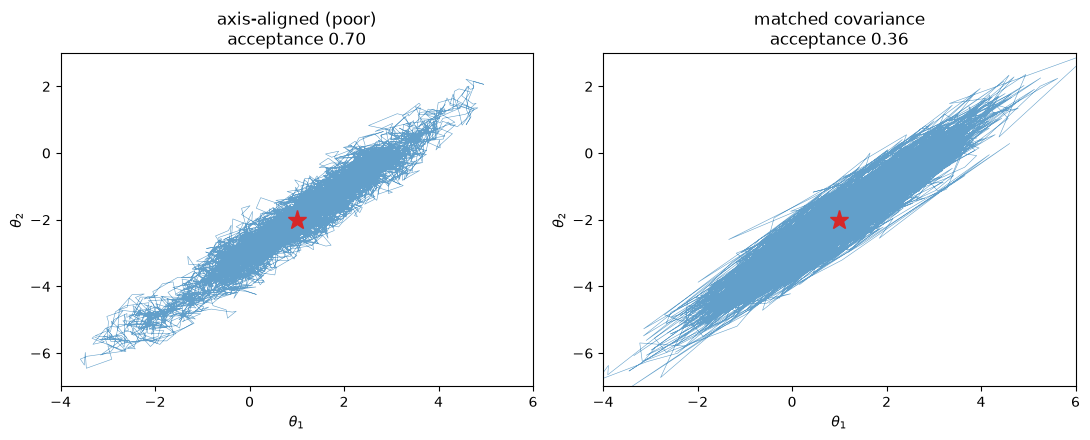

In [5]:
mean = np.array([1.0, -2.0])
covariance = np.array([[2.0, 1.9], [1.9, 2.0]])        # strongly degenerate
precision = np.linalg.inv(covariance)

def log_banana(theta):
    offset = np.asarray(theta) - mean
    return -0.5 * offset @ precision @ offset

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
proposals = [("axis-aligned (poor)", GaussianRandomWalk(np.eye(2) * 0.1)),
             ("matched covariance", GaussianRandomWalk(covariance, scale=1.7))]

for axis, (label, proposal) in zip(axes, proposals):
    run = MetropolisHastings(log_banana, proposal).sample(
        mean, 8000, np.random.default_rng(2)
    )
    axis.plot(run.samples[:, 0], run.samples[:, 1], lw=0.4, alpha=0.7)
    axis.plot(*mean, "C3*", ms=14)
    axis.set_xlim(-4, 6)
    axis.set_ylim(-7, 3)
    axis.set_xlabel(r"$\theta_1$")
    axis.set_ylabel(r"$\theta_2$")
    axis.set_title(f"{label}\nacceptance {run.acceptance_rate:.2f}")
plt.tight_layout()
plt.show()

## 5. Reproducibility

The sampler requires an explicit `numpy.random.Generator` and never uses the
global `np.random`.

In [6]:
proposal = GaussianRandomWalk(covariance, scale=1.7)
first = MetropolisHastings(log_banana, proposal).sample([0.0, 0.0], 1000, np.random.default_rng(42))
again = MetropolisHastings(log_banana, proposal).sample([0.0, 0.0], 1000, np.random.default_rng(42))
print("same seed, byte-identical:", np.array_equal(first.samples, again.samples))

try:
    MetropolisHastings(log_banana, proposal).sample([0.0, 0.0], 10, rng=42)
except TypeError as error:
    print("a bare integer seed is refused:", error)

same seed, byte-identical: True
a bare integer seed is refused: pass an explicit numpy.random.Generator, e.g. np.random.default_rng(seed); the global np.random is never used


## 6. The Union2.1 posterior

In [7]:
from snia.data.union21 import load_union21
from snia.data.likelihood import Union21Likelihood

z, mu, cov = load_union21()
likelihood = Union21Likelihood(z, mu, cov)
prior = UniformPrior(lower=[0.0, -1.0], upper=[2.0, 3.0])    # the exercise's box
posterior = Posterior(likelihood.log_likelihood, prior)

print("posterior at LCDM:", posterior([0.3, 0.7]))
print("posterior outside the box:", posterior([5.0, 0.7]))

posterior at LCDM: -272.5613707336597
posterior outside the box: -inf


In [8]:
warmup = MetropolisHastings(
    posterior, GaussianRandomWalk(np.diag([0.05**2, 0.08**2]))
).sample([0.3, 0.7], 4000, np.random.default_rng(0))

tuned_covariance = np.cov(warmup.samples[1000:].T)

print(f"warm-up acceptance {warmup.acceptance_rate:.3f}")
print("tuned proposal covariance:")
print(tuned_covariance)

warm-up acceptance 0.660
tuned proposal covariance:
[[0.0131547  0.01978836]
 [0.01978836 0.04460138]]


In [9]:
production = run_chains(
    posterior,
    GaussianRandomWalk(tuned_covariance, scale=1.7),      # frozen, not adapting
    initial_states=[[0.2, 0.5], [0.45, 0.95], [0.1, 0.85], [0.5, 0.6]],
    n_steps=40000,
    rng=np.random.default_rng(1),
)
retained = production.burned(4000)
samples = retained.flat()

print(f"samples shape {retained.samples.shape}   (chains, steps, parameters)")
print(f"acceptance    {np.round(production.acceptance_rate, 3)}\n")

omega_m, omega_lambda = samples[:, 0], samples[:, 1]
print(f"Omega_m = {omega_m.mean():+.4f} +- {omega_m.std():.4f}")
print(f"Omega_L = {omega_lambda.mean():+.4f} +- {omega_lambda.std():.4f}")
print(f"Omega_k = {(1 - omega_m - omega_lambda).mean():+.4f} +- {(1 - omega_m - omega_lambda).std():.4f}")
print(f"q0      = {(omega_m / 2 - omega_lambda).mean():+.4f} +- {(omega_m / 2 - omega_lambda).std():.4f}")

samples shape (4, 36000, 2)   (chains, steps, parameters)
acceptance    [0.339 0.331 0.333 0.341]

Omega_m = +0.2789 +- 0.1119
Omega_L = +0.6590 +- 0.2093
Omega_k = +0.0621 +- 0.3093
q0      = -0.5196 +- 0.1650


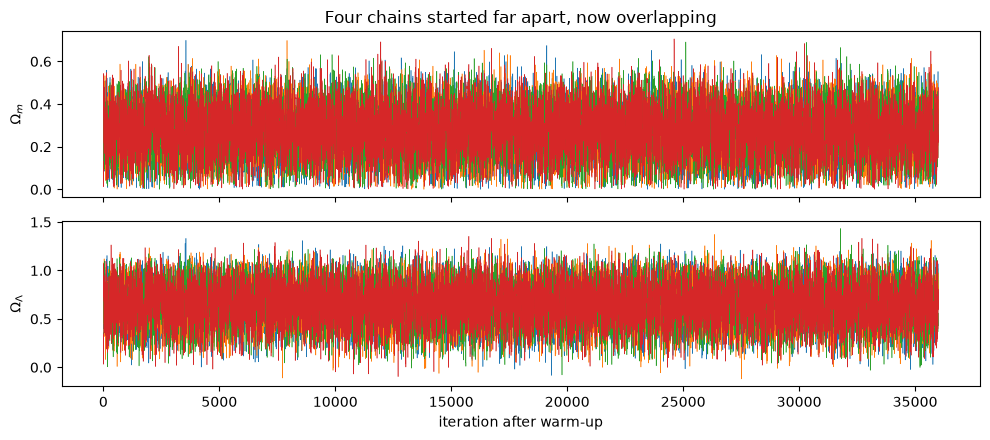

In [10]:
figure, axes = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)
for chain in range(retained.n_chains):
    axes[0].plot(retained.samples[chain, :, 0], lw=0.4)
    axes[1].plot(retained.samples[chain, :, 1], lw=0.4)
axes[0].set_ylabel(r"$\Omega_m$")
axes[1].set_ylabel(r"$\Omega_\Lambda$")
axes[1].set_xlabel("iteration after warm-up")
axes[0].set_title("Four chains started far apart, now overlapping")
plt.tight_layout()
plt.show()

## 7. Did it converge?

| Quantity | Question | Bad sign |
| --- | --- | --- |
| $\tau_{\rm int}$ | How many steps before a draw is effectively new? | large next to $N$ |
| $N_{\rm eff} = N/\tau_{\rm int}$ | How many *independent* draws do I really have? | far below $N$ |
| ${\rm MCSE} = s/\sqrt{N_{\rm eff}}$ | How precisely is the mean known? | comparable to $s$ |
| $\hat{R}$ | Do chains started far apart agree? | $> 1.01$ |
| $j_\star$, $r$ | Is the chain white on long timescales? | $j_\star < 20$, $r > 0.01$ |

**Correlation.** Successive draws are not independent: the chain takes a while
to forget where it was. $\tau_{\rm int} = 1 + 2\sum_{\ell\ge1}\rho_\ell$ measures
that memory, and $N$ draws therefore carry the information of about
$N/\tau_{\rm int}$ independent ones. **Chain length is not sample size** — the
effective count is what sets the error bar on anything reported.

**Agreement.** Split-$\hat{R}$ compares the spread *between* chains with the
spread *within* them. Each chain is cut in half first, which is what catches a
chain still drifting: if every chain drifts the same way there is no
between-chain spread at all, but the two halves of each chain end up in
different places.

**Stationarity.** Transformed to Fourier space, a converged chain is flat at
small $j$ (long timescales) and falls off at large $j$. Dunkley et al. fit
$P(k)=P_0/[1+(k/k_\star)^{\alpha}]$ and require $j_\star>20$ and
$r=P_0/(Ns^2)<0.01$. That $r$ turns out to be *exactly* $1/N_{\rm eff}$, so it
is the same information arriving by a completely different route — which makes
the two a genuine cross-check rather than a repetition.

In [11]:
from snia.diagnostics.autocorr import (
    autocorrelation, integrated_time, effective_sample_size, monte_carlo_error,
)
from snia.diagnostics.gelman_rubin import rank_normalized_rhat
from snia.diagnostics.spectral import fit_dunkley

chains = retained.samples          # (chains, steps, parameters)
names = ["Omega_m", "Omega_Lambda"]
spread = samples.std(axis=0)

tau = integrated_time(chains)
ess = effective_sample_size(chains)
mcse = monte_carlo_error(chains)
rhat = rank_normalized_rhat(chains)

print(f"{'':14s} {'tau_int':>8} {'ESS':>8} {'MCSE':>9} {'MCSE/sd':>9} {'Rhat':>8}")
for i, name in enumerate(names):
    print(f"{name:14s} {tau[i]:8.2f} {ess[i]:8.0f} {mcse[i]:9.5f} "
          f"{mcse[i] / spread[i]:9.4f} {rhat[i]:8.4f}")

verdicts = [fit_dunkley(chains[c, :, i]).passes
            for i in range(chains.shape[2]) for c in range(chains.shape[0])]
print(f"\nof {chains.shape[1]:,} steps per chain, only about "
      f"{chains.shape[1] / tau.max():.0f} are independent")
print(f"the mean is known to {100 * (mcse / spread).max():.1f}% of the posterior width")
print(f"Dunkley test: {sum(verdicts)}/{len(verdicts)} chain-parameter pairs pass")
print(f"Rhat all below 1.01: {bool(np.all(rhat < 1.01))}")

                tau_int      ESS      MCSE   MCSE/sd     Rhat
Omega_m            7.46    19303   0.00081    0.0072   1.0001
Omega_Lambda       7.64    18846   0.00152    0.0073   1.0002



of 36,000 steps per chain, only about 4712 are independent
the mean is known to 0.7% of the posterior width
Dunkley test: 8/8 chain-parameter pairs pass
Rhat all below 1.01: True


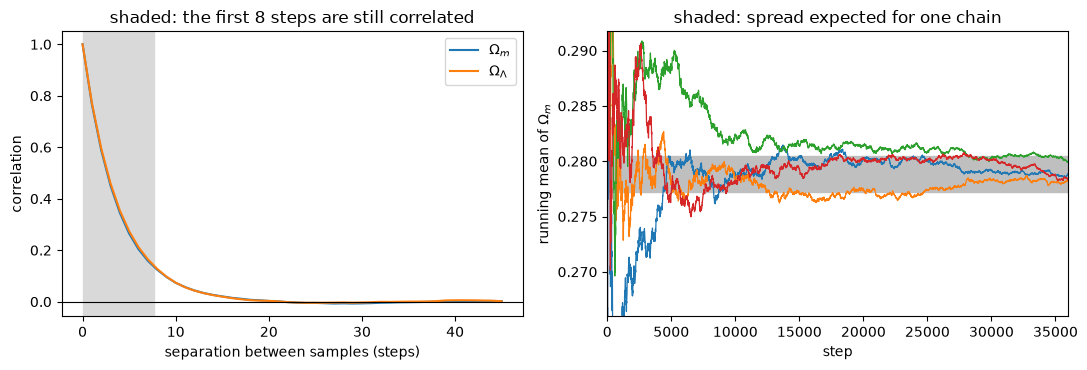

In [12]:
figure, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))

# left: what tau_int measures -- how long the chain remembers
rho = autocorrelation(chains, max_lag=45)
for i, label in enumerate([r"$\Omega_m$", r"$\Omega_\Lambda$"]):
    left.plot(rho[:, i], label=label)
left.axvspan(0, tau.max(), color="0.85", zorder=0)
left.axhline(0, color="k", lw=0.8)
left.set_xlabel("separation between samples (steps)")
left.set_ylabel("correlation")
left.set_title(f"shaded: the first {tau.max():.0f} steps are still correlated")
left.legend()

# right: what MCSE measures -- how well the mean is pinned down
n_chains, n_steps, _ = chains.shape
final = chains[:, :, 0].mean()
one_chain = mcse[0] * np.sqrt(n_chains)     # a single chain has sqrt(n) less data
for c in range(n_chains):
    right.plot(np.cumsum(chains[c, :, 0]) / np.arange(1, n_steps + 1), lw=0.9)
right.axhspan(final - one_chain, final + one_chain, color="0.75", zorder=0)
right.set_xlim(0, n_steps)
right.set_ylim(final - 8 * one_chain, final + 8 * one_chain)
right.set_xlabel("step")
right.set_ylabel(r"running mean of $\Omega_m$")
right.set_title("shaded: spread expected for one chain")

plt.tight_layout()
plt.show()

The left panel is $\tau_{\rm int}$ made visible: draws closer together than the
shaded width still carry each other's information. The right panel is the MCSE:
four chains that started far apart all settle into a band whose width is the
quoted uncertainty on the mean.

A caveat that no diagnostic removes. Every one of these can be passed by a chain
that explored only one mode of a multimodal posterior: it will look stationary,
its spectrum will be white, and several chains started nearby will agree
beautifully with each other. That is why the chains are started **dispersed**,
and why the thresholds are guidelines rather than proofs.

### Does the sampler reproduce the brute-force grid?

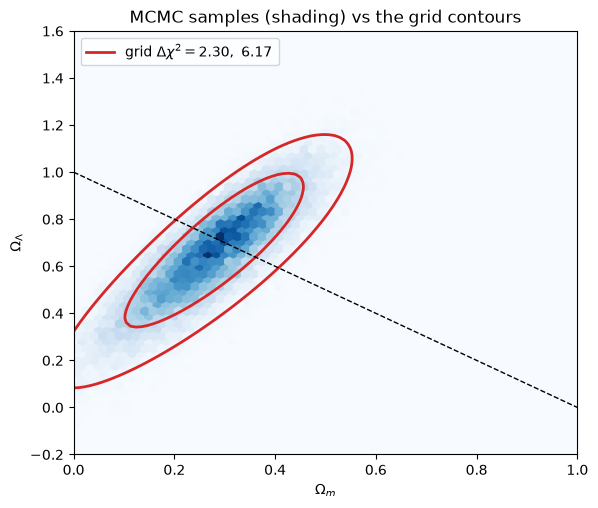

In [13]:
omega_m_axis = np.linspace(0.0, 1.0, 90)
omega_lambda_axis = np.linspace(-0.2, 1.6, 110)
chi2 = np.array([[likelihood.chi2((om, ol)) for om in omega_m_axis]
                 for ol in omega_lambda_axis])
chi2 -= chi2[np.isfinite(chi2)].min()

plt.figure(figsize=(6.5, 5.5))
plt.hexbin(omega_m, omega_lambda, gridsize=60, cmap="Blues",
           extent=(0, 1, -0.2, 1.6))
plt.contour(omega_m_axis, omega_lambda_axis, chi2, levels=[2.30, 6.17],
            colors="C3", linewidths=2)
plt.plot([0, 1], [1, 0], "k--", lw=1)
plt.plot([], [], "C3-", lw=2, label=r"grid $\Delta\chi^2 = 2.30,\ 6.17$")
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$\Omega_\Lambda$")
plt.title("MCMC samples (shading) vs the grid contours")
plt.legend(loc="upper left")
plt.show()

## 8. Cross-check: sample $\mathcal{M}$ instead of marginalizing it

The analytic result $\chi^2 = A - B^2/E$ assumes a flat prior on $\mathcal{M}$.
Running a **three-parameter** chain with $\mathcal{M}$ sampled must give the same
$(\Omega_m, \Omega_\Lambda)$ contours. A sign error in $B$, or a swapped
residual convention, would separate them.

In [14]:
prior_3d = UniformPrior([0.0, -1.0, 41.0], [2.0, 3.0, 45.0])
posterior_3d = Posterior(
    lambda theta: -0.5 * likelihood.chi2_at_offset(theta[:2], theta[2]),
    prior_3d,
)

start_covariance = np.zeros((3, 3))
start_covariance[:2, :2] = tuned_covariance
start_covariance[2, 2] = 0.004**2

warmup_3d = MetropolisHastings(posterior_3d, GaussianRandomWalk(start_covariance)).sample(
    [0.3, 0.7, 43.17], 12000, np.random.default_rng(2)
)

production_3d = run_chains(
    posterior_3d,
    GaussianRandomWalk(np.cov(warmup_3d.samples[1500:].T), scale=1.4),
    [[0.2, 0.5, 43.1], [0.45, 0.95, 43.2], [0.1, 0.85, 43.15], [0.5, 0.6, 43.25]],
    40000,
    np.random.default_rng(3),
)
samples_3d = production_3d.burned(3000).flat()

print(f"{'':10s} {'2 parameters':>22s} {'3 parameters':>22s}")
for column, name in [(0, "Omega_m"), (1, "Omega_L")]:
    two, three = samples[:, column], samples_3d[:, column]
    print(f"{name:10s} {two.mean():10.4f} +- {two.std():.4f} "
          f"{three.mean():10.4f} +- {three.std():.4f}")
print(f"\nM sampled  = {samples_3d[:, 2].mean():.4f} +- {samples_3d[:, 2].std():.4f}")
print(f"M analytic = {likelihood.m_offset((0.295, 0.705)):.4f}   (B/E)")

                     2 parameters           3 parameters
Omega_m        0.2789 +- 0.1119     0.2807 +- 0.1113
Omega_L        0.6590 +- 0.2093     0.6611 +- 0.2082

M sampled  = 43.1737 +- 0.0326
M analytic = 43.1683   (B/E)


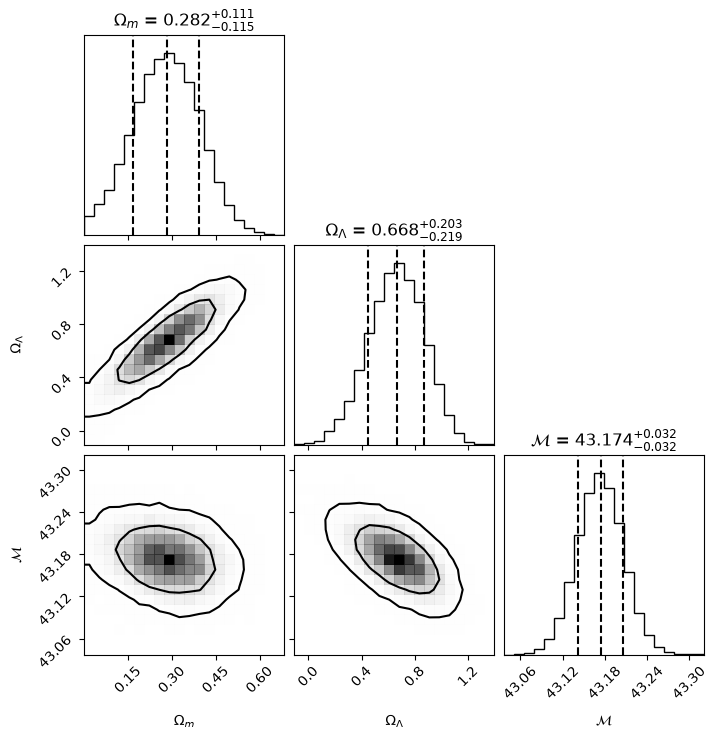

In [15]:
import corner

figure = corner.corner(
    samples_3d,
    labels=[r"$\Omega_m$", r"$\Omega_\Lambda$", r"$\mathcal{M}$"],
    levels=(0.683, 0.954),
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    plot_datapoints=False,
)
plt.show()

## Summary

| object | role |
| --- | --- |
| `UniformPrior(lower, upper)` | flat box prior, `-inf` outside |
| `Posterior(log_likelihood, log_prior)` | their sum, skipping the likelihood when the prior already rejects |
| `GaussianRandomWalk(cov, scale)` | correlated random walk, factored once |
| `MetropolisHastings(log_target, proposal).sample(...)` | one chain |
| `run_chains(...)` | dispersed chains, shape `(chains, steps, parameters)` |
| `snia.diagnostics` | `integrated_time`, `effective_sample_size`, `monte_carlo_error`, `rank_normalized_rhat`, `fit_dunkley` |
